# **Simulation Hedy 2025**

Team: TU Wien Space Team \
Project: Lamarr \
Rocket: Hedy \


## Installs

In this section all needed libraries are installed and the needed classes imported

In [1]:
pip install rocketpy

Defaulting to user installation because normal site-packages is not writeable
Note: you may need to restart the kernel to use updated packages.



[notice] A new release of pip is available: 25.1.1 -> 25.2
[notice] To update, run: C:\Users\wattikan\AppData\Local\Microsoft\WindowsApps\PythonSoftwareFoundation.Python.3.13_qbz5n2kfra8p0\python.exe -m pip install --upgrade pip


In [2]:
pip install CoolProp

Defaulting to user installation because normal site-packages is not writeable
Note: you may need to restart the kernel to use updated packages.



[notice] A new release of pip is available: 25.1.1 -> 25.2
[notice] To update, run: C:\Users\wattikan\AppData\Local\Microsoft\WindowsApps\PythonSoftwareFoundation.Python.3.13_qbz5n2kfra8p0\python.exe -m pip install --upgrade pip


In [3]:
from rocketpy import Environment, Rocket, Flight, Fluid, LiquidMotor, CylindricalTank, MassFlowRateBasedTank, TrapezoidalFins, FreeFormFins, EllipticalFins, RailButtons, NoseCone, Tail, Parachute, CompareFlights
from math import exp
from math import pi
import datetime
import json
import CoolProp.CoolProp as CP
from CoolProp.CoolProp import PropsSI
from rocketpy.mathutils import Function

## Configuration (new)

Several config dictionaries define different flight parameters -> the different flight objects are stored in a list to later compare them with RocketPy's comparison tools

### Flags

In [5]:
# the file paths of all dictionaries to be simulated
"""
config_dict_list = [
    "22deg.json",
    "23deg.json",
    "24deg.json",
    "25deg.json",
    "26deg.json",
    "27deg.json",
    "28deg.json",
    "29deg.json",
    "30deg.json",
    "31deg.json",
    "32deg.json",
    "33deg.json",
    "34deg.json"
]
"""
config_dict_list = [
    "dictionaries/27deg.json"
]
flag_lists = []

for config in config_dict_list:
    print(f"Config: {config}")
    # load the config json into a dictionary
    with open(config, "rt") as f:
        config_dict = json.loads(f.read())

    # flags initialisation
    # select whether preset mass from config sheet is used...
    use_preset_mass = config_dict["Flags"]["flag"]["use_preset_mass"]["Value"]
    # ...or highest geometrically possible mass is used
    # if both these flags are set to False, the mass is calculated through (massflow * burntime * (1 + overfill percentage))
    use_max_n2_mass = config_dict["Flags"]["flag"]["use_max_nitrogen_mass"]["Value"]
    use_max_mass = config_dict["Flags"]["flag"]["use_max_mass"]["Value"] # for fuel and lox
    # select whether thrust is a constant integer or a .csv file is provided
    use_static_thrust = config_dict["Flags"]["flag"]["use_static_thrust"]["Value"]
    # select whether the simulation adds ice weight to total rocket weight
    account_for_ice = config_dict["Flags"]["flag"]["account_for_ice"]["Value"]
    # select whether freeform fins or trapezoidal fins are used in the simulation
    use_freeform_fins = config_dict["Flags"]["flag"]["use_freeform_fins"]["Value"]
    # select whether the simulation terminates on apogee
    terminate_on_apogee = config_dict["Flags"]["flag"]["terminate_on_apogee"]["Value"]

    # check for valid flag selection (max and preset cannot be used simultaneously)
    if use_preset_mass and use_max_mass:
        print("Flag selection error")
    
    flag_lists.append({
        "use_preset_mass": use_preset_mass,
        "use_max_n2_mass": use_max_n2_mass,
        "use_max_mass": use_max_mass,
        "use_static_thrust": use_static_thrust,
        "account_for_ice": account_for_ice,
        "use_freeform_fins": use_freeform_fins,
        "terminate_on_apogee": terminate_on_apogee
    })


Config: dictionaries/27deg.json


### Environment

Fetching elevation from open-elevation.com for lat=39.12368, lon=-8.03333...
Elevation received: 161.0 m

Gravity Details

Acceleration of gravity at surface level:    9.7798 m/s²
Acceleration of gravity at  80.000 km (ASL): 9.5379 m/s²


Launch Site Details

Launch Date: 2024-12-24 13:00:00 UTC | 2024-12-24 13:00:00 Europe/Lisbon
Launch Site Latitude: 39.12368°
Launch Site Longitude: -8.03333°
Reference Datum: SIRGAS2000
Launch Site UTM coordinates: 166021.44 W|E    0.00 N
Launch Site UTM zone: 31N
Launch Site Surface Elevation: 161.0 m


Atmospheric Model Details

Atmospheric Model Type: standard_atmosphere
standard_atmosphere Maximum Height: 80.000 km

Surface Atmospheric Conditions

Surface Wind Speed: 0.00 m/s
Surface Wind Direction: 0.00°
Surface Wind Heading: 0.00°
Surface Pressure: 994.36 hPa
Surface Temperature: 287.11 K
Surface Air Density: 1.207 kg/m³
Surface Speed of Sound: 339.63 m/s


Earth Model Details

Earth Radius at Launch site: 6378.14 km
Semi-major Axis: 6378.14 km

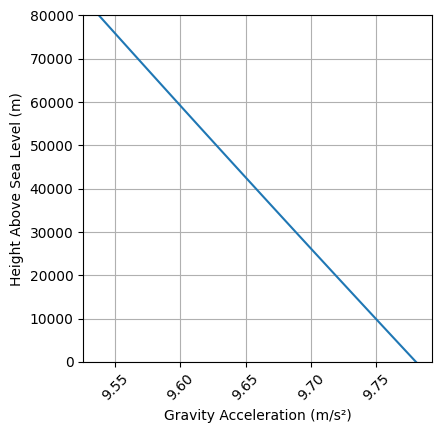



Atmospheric Model Plots


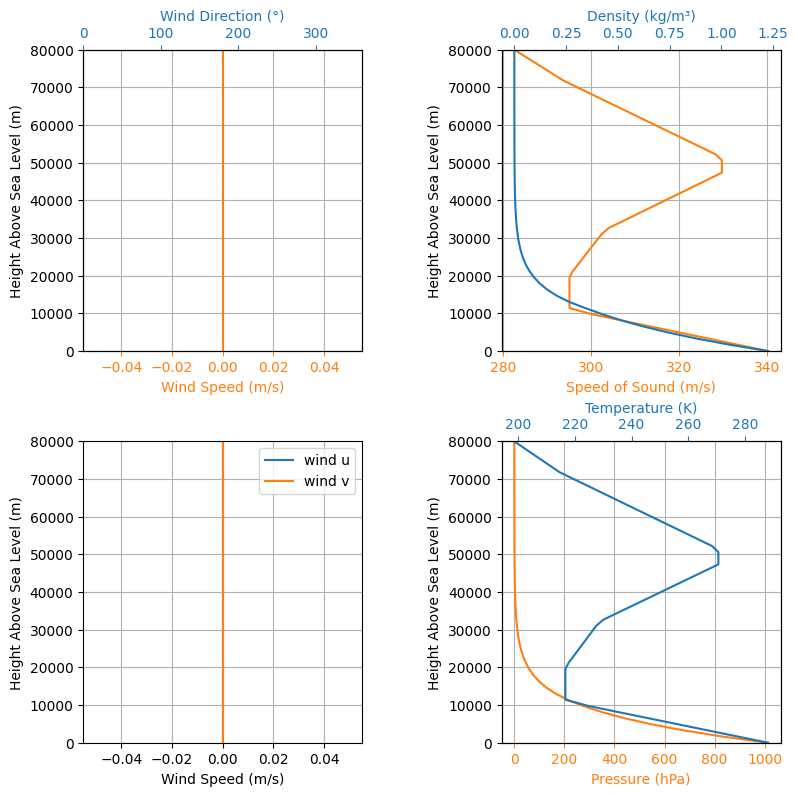

In [ ]:
env_lists = []

for config in config_dict_list:
    latitude = config_dict["Environment"]["env"]["latitude"]["Value"]
    longitude = config_dict["Environment"]["env"]["longitude"]["Value"]
    timezone = config_dict["Environment"]["env"]["timezone"]["Value"]
    year = int(config_dict["Environment"]["env"]["date"]["year"])
    month = int(config_dict["Environment"]["env"]["date"]["month"])
    day = int(config_dict["Environment"]["env"]["date"]["day"])
    hour = int(config_dict["Environment"]["env"]["date"]["hour"])
    minute = int(config_dict["Environment"]["env"]["date"]["minute"])
    second = int(config_dict["Environment"]["env"]["date"]["second"])

    # environment config // if environment should be with forecast, this code section must be adapted
    env_normal = Environment()
    
    date = datetime.datetime(
        year,
        month,
        day,
        hour,
        minute,
        second
    )
    
    env_normal.set_location(
        latitude = latitude,
        longitude = longitude
    )
    env_normal.set_elevation("Open-Elevation")
    env_normal.set_atmospheric_model(type = "standard_atmosphere")
    env_normal.set_date(
        date,
        timezone = timezone
    )
    env_normal.all_info()
    env_lists.append({"env_normal": env_normal})

### Propulsion

Burntime: 8.257380929591976
Nozzle Details
Nozzle Radius: 0.0375 m

Motor Details
Total Burning Time: 8.257380929591976 s
Total Propellant Mass: 9.140 kg
Structural Mass Ratio: 0.000
Average Propellant Exhaust Velocity: 2000.000 m/s
Average Thrust: 2000.000 N
Maximum Thrust: 2000.0 N at 0.0 s after ignition.
Total Impulse: 16514.762 Ns



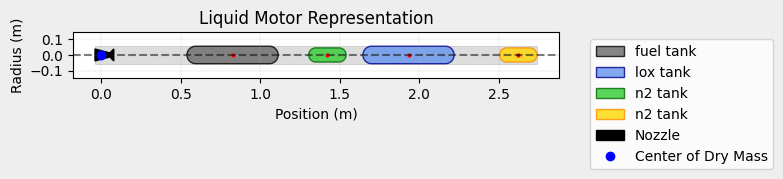

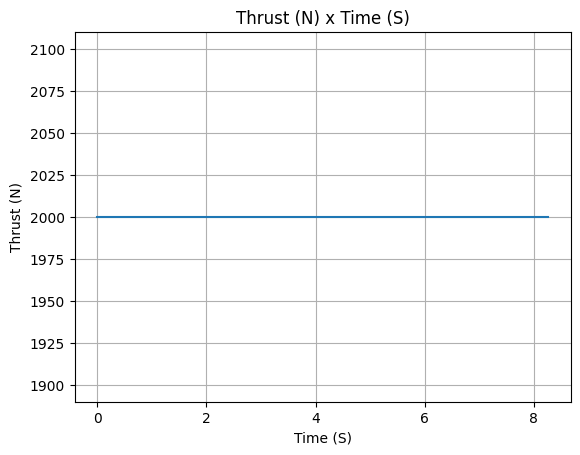

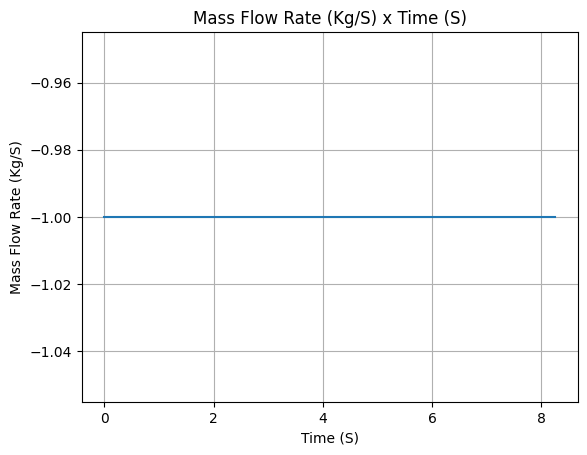

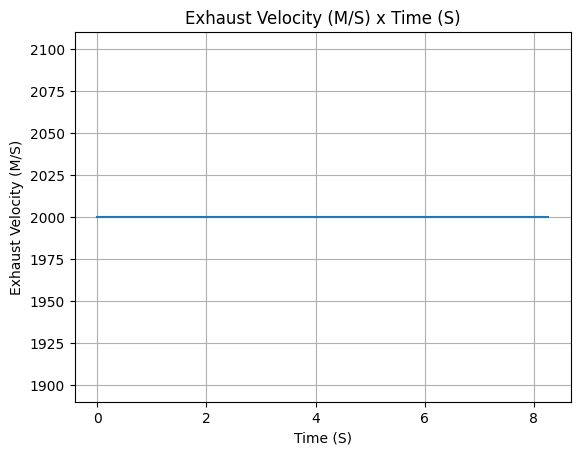

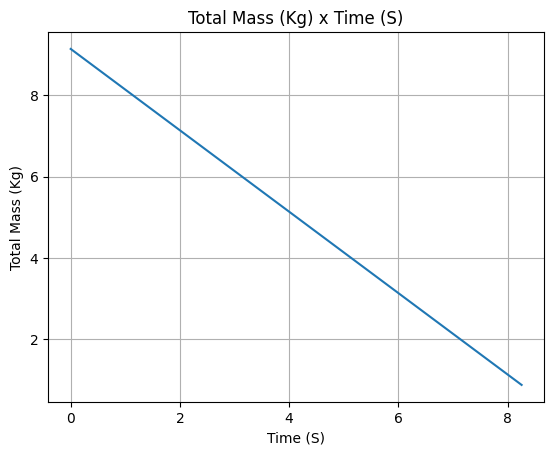

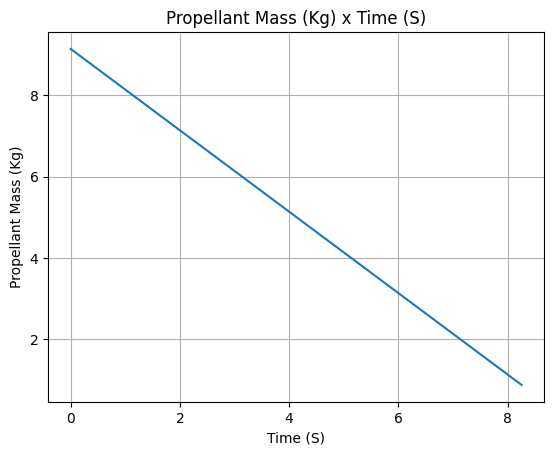

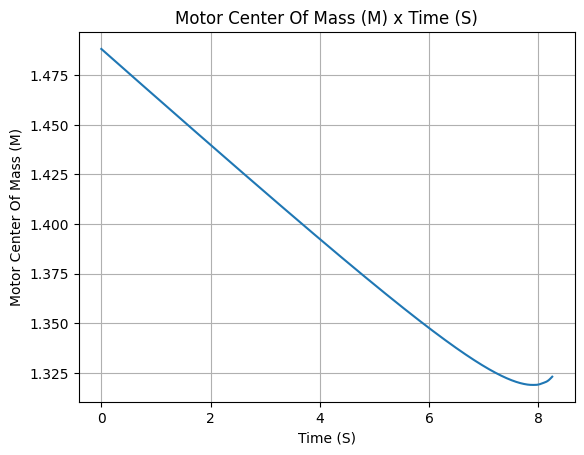

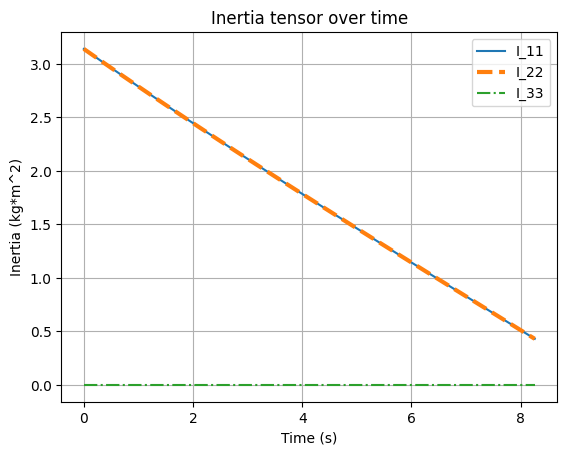

In [ ]:
propulsion_lists = []

for config in config_dict_list:
    flag_list = flag_lists[config_dict_list.index(config)]

    # preset initialisation
    t_burn = config_dict["Motor"]["presets"]["burn_time"]["Value"]
    t_holddown = config_dict["Motor"]["presets"]["holddown_time"]["Value"]

    if t_holddown > t_burn:
        print("Holddown time too long -> Time error")

    overfill_percentage = config_dict["Motor"]["presets"]["overfill_percentage"]["Value"]

    if flag_list["use_static_thrust"]:
        thrust = lambda t: config_dict["Motor"]["presets"]["thrust"]["Value"]
    else:
        thrust = config_dict["Motor"]["presets"]["thrust"]["Value"] # should contain a file path string -> needs to be tested
    
    # geometrical initialisation
    length_n2_tank = config_dict["Motor"]["nitrogen_tank"]["length"]["Value"]
    length_fuel_tank = config_dict["Motor"]["ethanol_tank"]["length"]["Value"]
    length_lox_tank = config_dict["Motor"]["lox_tank"]["length"]["Value"]

    outer_diameter_n2_tank = config_dict["Motor"]["nitrogen_tank"]["outer_diameter"]["Value"]
    outer_diameter_fuel_tank = config_dict["Motor"]["ethanol_tank"]["outer_diameter"]["Value"]
    outer_diameter_lox_tank = config_dict["Motor"]["lox_tank"]["outer_diameter"]["Value"]

    thickness_n2_tank = config_dict["Motor"]["nitrogen_tank"]["thickness"]["Value"]
    thickness_fuel_tank = config_dict["Motor"]["ethanol_tank"]["thickness"]["Value"]
    thickness_lox_tank = config_dict["Motor"]["lox_tank"]["thickness"]["Value"]

    cg_ethanol_tank = config_dict["Motor"]["ethanol_tank"]["CG"]["Value"]
    cg_lox_tank = config_dict["Motor"]["lox_tank"]["CG"]["Value"]
    cg_n2_tank_ethanol = config_dict["Motor"]["nitrogen_tank"]["CG_ethanol"]["Value"]
    cg_n2_tank_lox = config_dict["Motor"]["nitrogen_tank"]["CG_lox"]["Value"]

    nozzle_diameter = config_dict["Motor"]["nozzle"]["diameter"]["Value"]
    nozzle_position = config_dict["Motor"]["nozzle"]["position"]["Value"]

    # fluid dynamical initialisation
    massflow_n2 = config_dict["Motor"]["nitrogen_tank"]["massflow"]["Value"]
    massflow_fuel = config_dict["Motor"]["ethanol_tank"]["massflow"]["Value"]
    massflow_lox = config_dict["Motor"]["lox_tank"]["massflow"]["Value"]

    temperature_n2 = config_dict["Motor"]["presets"]["nitrogen_temperature"]["Value"]
    temperature_fuel = config_dict["Motor"]["presets"]["ethanol_temperature"]["Value"]
    temperature_lox = config_dict["Motor"]["presets"]["lox_temperature"]["Value"]

    pressure_n2 = config_dict["Motor"]["presets"]["nitrogen_pressure"]["Value"]
    pressure_fuel = config_dict["Motor"]["presets"]["ethanol_pressure"]["Value"]
    pressure_lox = config_dict["Motor"]["presets"]["lox_pressure"]["Value"]

    # geometrical calculations
    inner_diameter_n2_tank = outer_diameter_n2_tank - (2 * thickness_n2_tank)
    inner_diameter_fuel_tank = outer_diameter_fuel_tank - (2 * thickness_fuel_tank)
    inner_diameter_lox_tank = outer_diameter_lox_tank - (2 * thickness_lox_tank)

    n2_tank_shape = CylindricalTank(radius=(inner_diameter_n2_tank/2), height=length_n2_tank, spherical_caps=True)
    fuel_tank_shape = CylindricalTank(radius=(inner_diameter_fuel_tank/2), height=length_fuel_tank, spherical_caps=True)
    lox_tank_shape = CylindricalTank(radius=(inner_diameter_lox_tank/2), height=length_lox_tank, spherical_caps=True)

    # fluid dynamical initialisation/calculation
    density_n2 = CP.PropsSI("D","T",temperature_n2,"P|gas",pressure_n2,"N2")
    density_fuel = CP.PropsSI("D", "T|liquid", temperature_fuel, "P", pressure_fuel, "ethanol")
    density_lox = CP.PropsSI("D", "T|liquid", temperature_lox, "P", pressure_lox, "oxygen")
    
    n2 = Fluid(name = "N2", density = density_n2)
    fuel = Fluid(name = "ethanol", density = density_fuel)
    lox = Fluid(name = "LOX", density = density_lox)

    # mass flags processing
    # calculate mass that is passed on to RocketPy considering the selected flags
    if flag_list["use_max_n2_mass"]:
        mass_n2 = n2_tank_shape.total_volume * density_n2
        # notify user if burn time is too long for available amount of n2 under given massflow
        if (mass_n2 / massflow_n2) < t_burn:
            print("Burntime too long or massflow too fast -> Nitrogen error")
    else:
        mass_n2 = massflow_n2 * t_burn * (1 + (overfill_percentage/100)) # if conversion from % is implemented in config generator -> remove /100

    if flag_list["use_preset_mass"]:
        mass_fuel = config_dict["Motor"]["presets"]["ethanol_mass"]["Value"]
        mass_lox = config_dict["Motor"]["presets"]["lox_mass"]["Value"]
    elif flag_list["use_max_mass"]:
        mass_fuel = fuel_tank_shape.total_volume * density_fuel
        mass_lox = lox_tank_shape.total_volume * density_lox

        #print(mass_fuel, mass_lox)
        # if max values are used, burn time needs to be adjusted as this is now the variable
        if (mass_fuel / massflow_fuel) < (mass_lox / massflow_lox):
            t_burn = mass_fuel / massflow_fuel
        else:
            t_burn = mass_lox / massflow_lox
    else:
        mass_fuel = massflow_fuel * t_burn * (1 + (overfill_percentage/100))
        mass_lox = massflow_lox * t_burn * (1 + (overfill_percentage/100))

    # finally the burn time is updated to account for the holddown time; the mass which contributes to the flight is updated as well
    t_burn = t_burn - t_holddown - 0.01 # - 0.01s has been added to avoid Python issues
    mass_fuel -= massflow_fuel * t_holddown
    mass_lox -= massflow_lox * t_holddown

    print(f"Burntime: {t_burn}")

    # mass flow rate tank model definitions
    n2_tank = MassFlowRateBasedTank(
        name="n2 tank",
        geometry=n2_tank_shape,
        flux_time=t_burn,
        initial_liquid_mass=0,
        initial_gas_mass=mass_n2,
        liquid_mass_flow_rate_in=0,
        liquid_mass_flow_rate_out=0,
        gas_mass_flow_rate_in=0,
        gas_mass_flow_rate_out=lambda t: massflow_n2,
        liquid=Fluid(name="irrelevant", density=0.0001),
        gas=n2
    )
    
    fuel_tank = MassFlowRateBasedTank(
        name="fuel tank",
        geometry=fuel_tank_shape,
        flux_time=t_burn,
        initial_liquid_mass=mass_fuel,
        initial_gas_mass=0, # can be neglected
        liquid_mass_flow_rate_in=0,
        liquid_mass_flow_rate_out=lambda t: massflow_fuel,
        gas_mass_flow_rate_in=lambda t: massflow_n2,
        gas_mass_flow_rate_out=0,
        liquid=fuel,
        gas=n2
    )

    lox_tank = MassFlowRateBasedTank(
        name="lox tank",
        geometry=lox_tank_shape,
        flux_time=t_burn,
        initial_liquid_mass=mass_lox,
        initial_gas_mass = 0, # can be neglected
        liquid_mass_flow_rate_in=0,
        liquid_mass_flow_rate_out=lambda t: massflow_lox,
        gas_mass_flow_rate_in=lambda t: massflow_n2,
        gas_mass_flow_rate_out=0,
        liquid=lox,
        gas = n2
    )

    propulsion_system = LiquidMotor(
        dry_mass=0.0001,
        dry_inertia=(0,0,0),
        center_of_dry_mass_position=0,
        nozzle_radius=(nozzle_diameter/2),
        nozzle_position=nozzle_position,
        thrust_source=thrust,
        burn_time=t_burn,
        coordinate_system_orientation="nozzle_to_combustion_chamber"
    )

    propulsion_system.add_tank(tank=fuel_tank, position=cg_ethanol_tank)
    propulsion_system.add_tank(tank=lox_tank, position=cg_lox_tank)
    propulsion_system.add_tank(tank=n2_tank, position=cg_n2_tank_ethanol)
    propulsion_system.add_tank(tank=n2_tank, position=cg_n2_tank_lox)

    propulsion_system.all_info()
    propulsion_lists.append({
        "t_burn": t_burn,
        "thrust": thrust,
        "mass_n2": mass_n2,
        "mass_fuel": mass_fuel,
        "mass_lox": mass_lox,
        "n2_tank": n2_tank,
        "fuel_tank": fuel_tank,
        "lox_tank": lox_tank,
        "propulsion_system": propulsion_system
    })


### Rocket

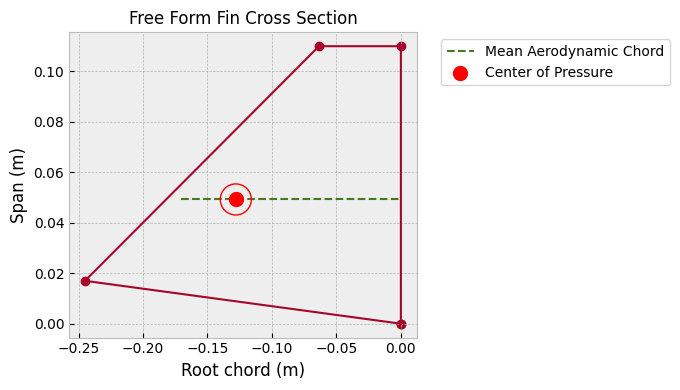


Inertia Details

Rocket Mass: 16.200 kg (without motor)
Rocket Dry Mass: 16.200 kg (with unloaded motor)
Rocket Loaded Mass: 25.340 kg
Rocket Structural Mass Ratio: 0.639
Rocket Inertia (with unloaded motor) 11: 16.800 kg*m2
Rocket Inertia (with unloaded motor) 22: 16.800 kg*m2
Rocket Inertia (with unloaded motor) 33: 0.025 kg*m2
Rocket Inertia (with unloaded motor) 12: 0.000 kg*m2
Rocket Inertia (with unloaded motor) 13: 0.000 kg*m2
Rocket Inertia (with unloaded motor) 23: 0.000 kg*m2

Geometrical Parameters

Rocket Maximum Radius: 0.0664 m
Rocket Frontal Area: 0.013851 m2

Rocket Distances
Rocket Center of Dry Mass - Center of Mass without Motor: 0.000 m
Rocket Center of Dry Mass - Nozzle Exit: 1.853 m
Rocket Center of Dry Mass - Center of Propellant Mass: 0.325 m
Rocket Center of Mass - Rocket Loaded Center of Mass: 0.117 m


Aerodynamics Lift Coefficient Derivatives

Nose Cone Lift Coefficient Derivative: 2.000/rad
Tail Lift Coefficient Derivative: -0.915/rad
Freeform Lift Coeffic

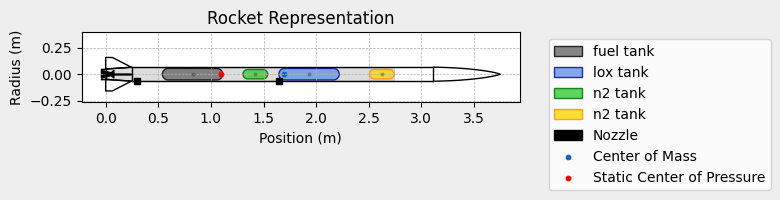


Mass Plots
----------------------------------------


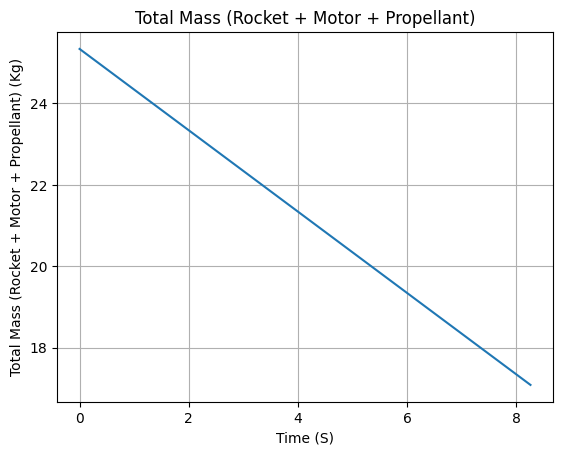

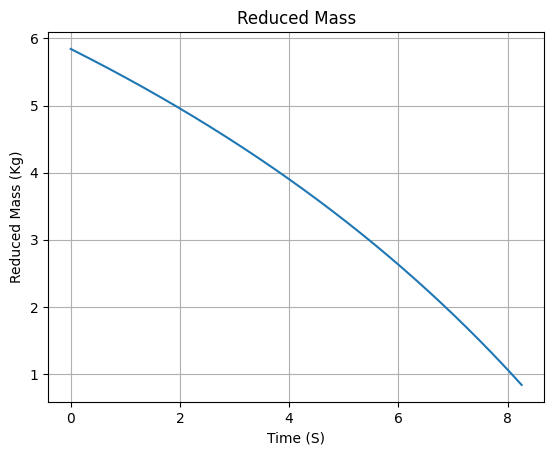


Aerodynamics Plots
----------------------------------------
Drag Plots
--------------------


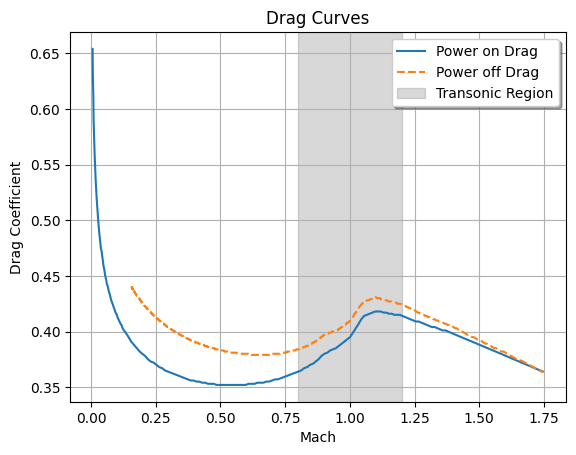


Stability Plots
--------------------


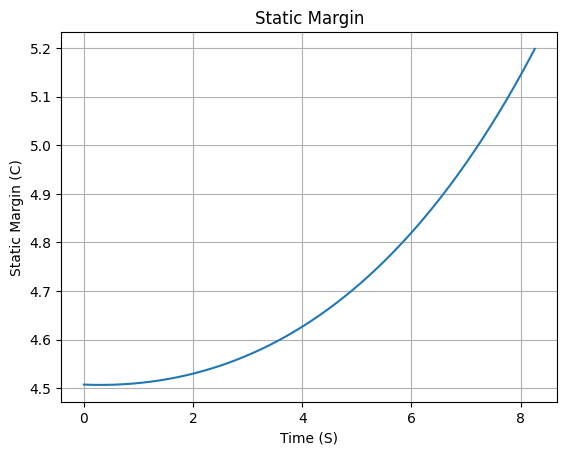

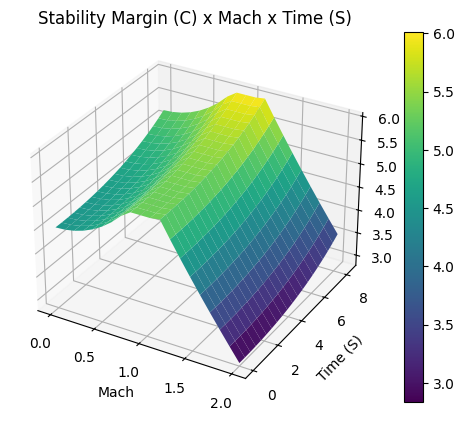


Thrust-to-Weight Plot
----------------------------------------


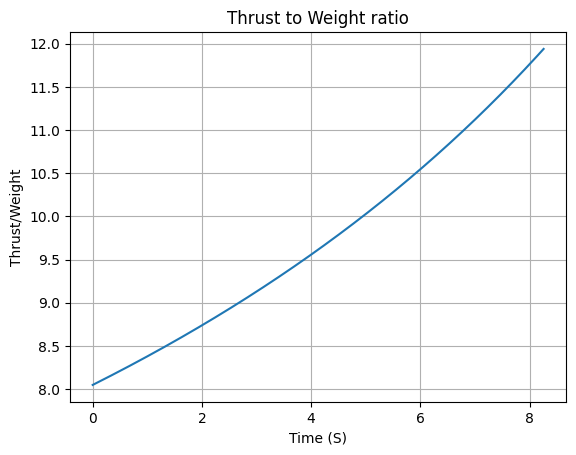

In [12]:
rocket_lists = []

for config in config_dict_list:
    flag_list = flag_lists[config_dict_list.index(config)]
    propulsion_list = propulsion_lists[config_dict_list.index(config)]

    # Rocket initialisation
    rocket_length = config_dict["Rocket"]["geometry"]["length"]["Value"]
    rocket_diameter = config_dict["Rocket"]["geometry"]["diameter"]["Value"]
    rocket_thickness = config_dict["Rocket"]["geometry"]["thickness"]["Value"]

    tailcone_diameter = config_dict["Rocket"]["tailcone"]["diameter"]["Value"]
    tailcone_length = config_dict["Rocket"]["tailcone"]["length"]["Value"]
    tailcone_cylindrical_height = config_dict["Rocket"]["tailcone"]["cylindrical_height"]["Value"]

    nosecone_length = config_dict["Rocket"]["nosecone"]["length"]["Value"]
    nosecone_kind = config_dict["Rocket"]["nosecone"]["kind"]["Value"]

    upper_railbutton_position = config_dict["Rocket"]["railbuttons"]["upper"]["Value"]
    lower_railbutton_position = config_dict["Rocket"]["railbuttons"]["lower"]["Value"]

    rocket_mass = config_dict["Rocket"]["geometry"]["weight"]["Value"]

    if flag_list["account_for_ice"]:
        rocket_mass += config_dict["Motor"]["presets"]["ice_mass"]["Value"]

    inertia_xy = config_dict["Rocket"]["geometry"]["inertia_xy"]["Value"]
    inertia_z = config_dict["Rocket"]["geometry"]["inertia_z"]["Value"]

    cg = config_dict["Rocket"]["geometry"]["CG"]["Value"]

    fin_amount = int(config_dict["Rocket"]["fins"]["amount"]["Value"])

    if flag_list["use_freeform_fins"]:
        fin_shape_points_amount = int(config_dict["Rocket"]["fins"]["shape_points_amount"]["Value"])
        fin_shape_points = []

        for index in range(0, fin_shape_points_amount):
            fin_shape_points.append(tuple(config_dict["Rocket"]["fins"][f"shape_point_{index+1}"]["Value"]))

        fin_shape_points = tuple(fin_shape_points)

        fin_set = FreeFormFins(
            n = fin_amount,
            shape_points = fin_shape_points,
            rocket_radius=(tailcone_diameter/2),
            name = "Freeform"
        )
    else:
        fin_name = config_dict["Rocket"]["fins"]["name"]["Value"]
        fin_position = config_dict["Rocket"]["fins"]["position"]["Value"]
        fin_root_chord = config_dict["Rocket"]["fins"]["root_chord"]["Value"]
        fin_tip_chord = config_dict["Rocket"]["fins"]["tip_chord"]["Value"]
        fin_span = config_dict["Rocket"]["fins"]["span"]["Value"]
        fin_sweep_length = config_dict["Rocket"]["fins"]["sweep_length"]["Value"]

        fin_set = TrapezoidalFins(
            n = fin_amount,
            root_chord = fin_root_chord,
            tip_chord = fin_tip_chord,
            span = fin_span,
            sweep_length = fin_sweep_length,
            name = fin_name,
            rocket_radius = rocket_diameter/2
        )

    fin_set.draw()

    # parachute init

    nosecone = NoseCone(
        length = config_dict["Rocket"]["nosecone"]["length"]["Value"], # why was "-10cm" added here in the original simulation?
        base_radius = rocket_diameter/2,
        kind = config_dict["Rocket"]["nosecone"]["kind"]["Value"]
    )

    tailcone = Tail(
        top_radius = (rocket_diameter/2),
        bottom_radius = (tailcone_diameter/2),
        length = tailcone_length,
        rocket_radius = (rocket_diameter/2)
    )

    # define Rocket & add parachutes
    
    hedy = Rocket(
        radius = (rocket_diameter/2),
        mass = rocket_mass,
        inertia = (inertia_xy, inertia_xy, inertia_z),
        power_off_drag = config_dict["Rocket"]["drag"]["power_off"]["Value"],
        power_on_drag = config_dict["Rocket"]["drag"]["power_on"]["Value"],
        center_of_mass_without_motor=cg,
        coordinate_system_orientation="tail_to_nose"
    )

    hedy.add_motor(propulsion_list["propulsion_system"], position = 0)
    hedy.add_surfaces(
        surfaces=[nosecone, tailcone, fin_set], 
        positions=[rocket_length, tailcone_length, 0]
    )

    hedy.set_rail_buttons(
        upper_button_position= upper_railbutton_position, 
        lower_button_position=lower_railbutton_position
    )



    hedy.add_parachute(
        name = "drogue",
        cd_s = config_dict["Rocket"]["drogue_parachute"]["cd_s"]["Value"],
        trigger = config_dict["Rocket"]["drogue_parachute"]["trigger"]["Value"],
        sampling_rate = config_dict["Rocket"]["drogue_parachute"]["sampling_rate"]["Value"],
        lag = config_dict["Rocket"]["drogue_parachute"]["lag"]["Value"],
        noise = tuple(config_dict["Rocket"]["drogue_parachute"]["noise"]["Value"])
    )
    hedy.add_parachute(
        name = "main",
        cd_s = config_dict["Rocket"]["main_parachute"]["cd_s"]["Value"],
        trigger = config_dict["Rocket"]["main_parachute"]["trigger"]["Value"],
        sampling_rate = config_dict["Rocket"]["main_parachute"]["sampling_rate"]["Value"],
        lag = config_dict["Rocket"]["main_parachute"]["lag"]["Value"],
        noise = tuple(config_dict["Rocket"]["main_parachute"]["noise"]["Value"])
    )
    hedy.all_info()
    rocket_lists.append({"hedy": hedy})


### Flight


Initial Conditions

Initial time: 0.000 s
Position - x: 0.00 m | y: 0.00 m | z: 161.00 m
Velocity - Vx: 0.00 m/s | Vy: 0.00 m/s | Vz: 0.00 m/s
Attitude (quaternions) - e0: 0.718 | e1: -0.001 | e2: 0.052 | e3: -0.694
Euler Angles - Spin φ : 45.00° | Nutation θ: -6.00° | Precession ψ: -133.00°
Angular Velocity - ω1: 0.00 rad/s | ω2: 0.00 rad/s | ω3: 0.00 rad/s
Initial Stability Margin: 4.507 c


Surface Wind Conditions

Frontal Surface Wind Speed: 0.00 m/s
Lateral Surface Wind Speed: 0.00 m/s


Launch Rail

Launch Rail Length: 11.0 m
Launch Rail Inclination: 84.00°
Launch Rail Heading: 133.00°


Rail Departure State

Rail Departure Time: 0.518 s
Rail Departure Velocity: 36.208 m/s
Rail Departure Stability Margin: 4.519 c
Rail Departure Angle of Attack: -0.000°
Rail Departure Thrust-Weight Ratio: 8.216
Rail Departure Reynolds Number: 3.250e+05


Burn out State

Burn out time: 8.257 s
Altitude at burn out: 2561.704 m (ASL) | 2400.704 m (AGL)
Rocket speed at burn out: 570.050 m/s
Freestrea

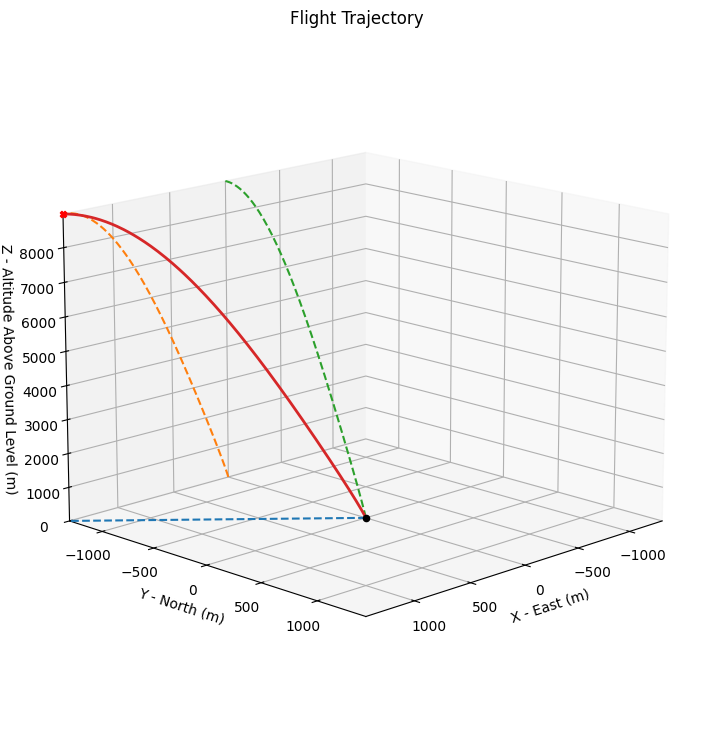



Trajectory Kinematic Plots



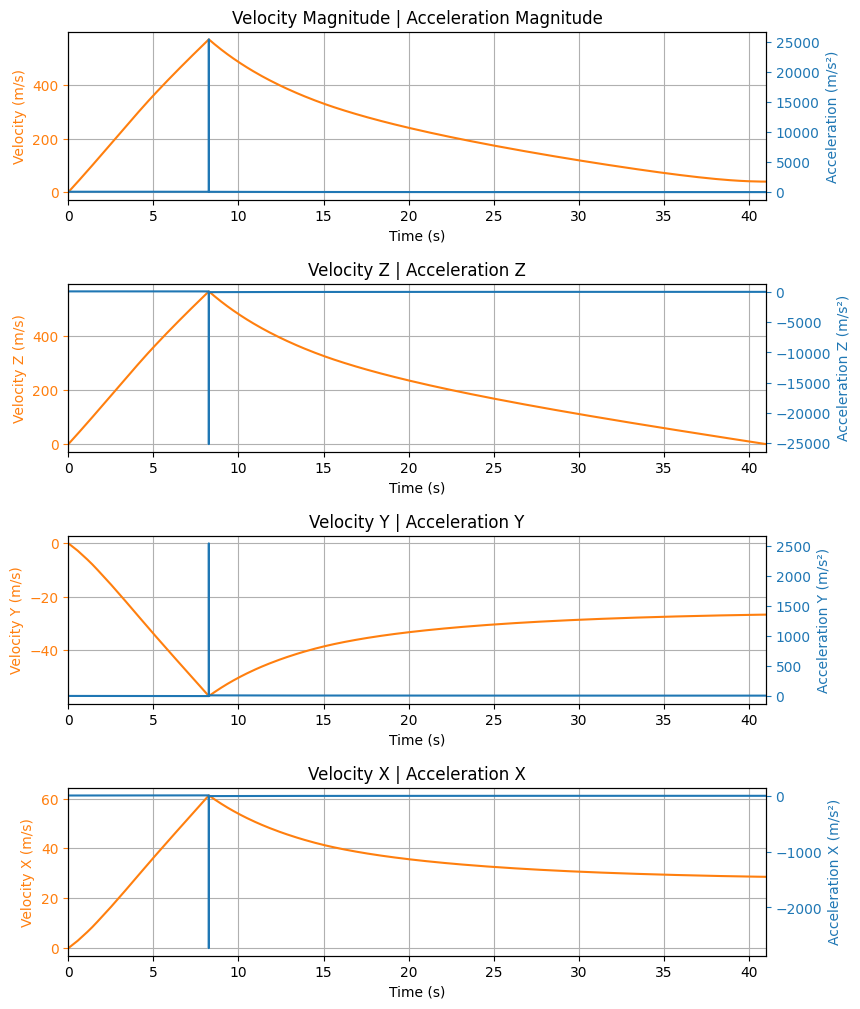



Angular Position Plots



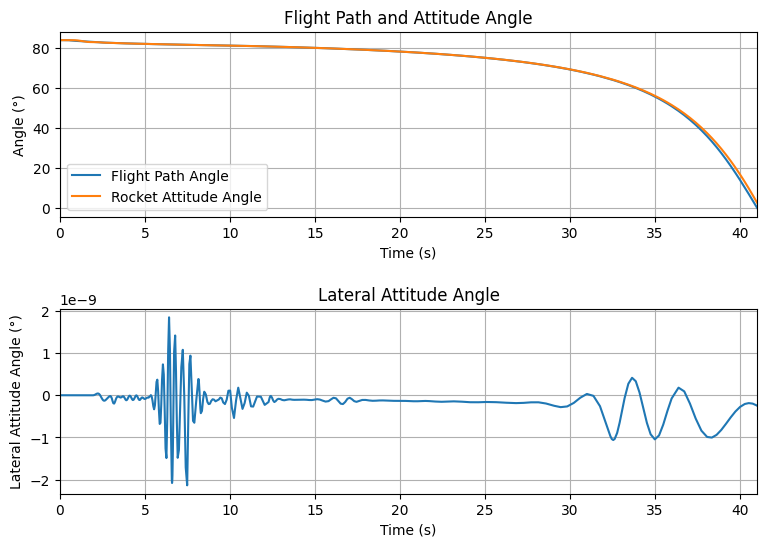



Path, Attitude and Lateral Attitude Angle plots



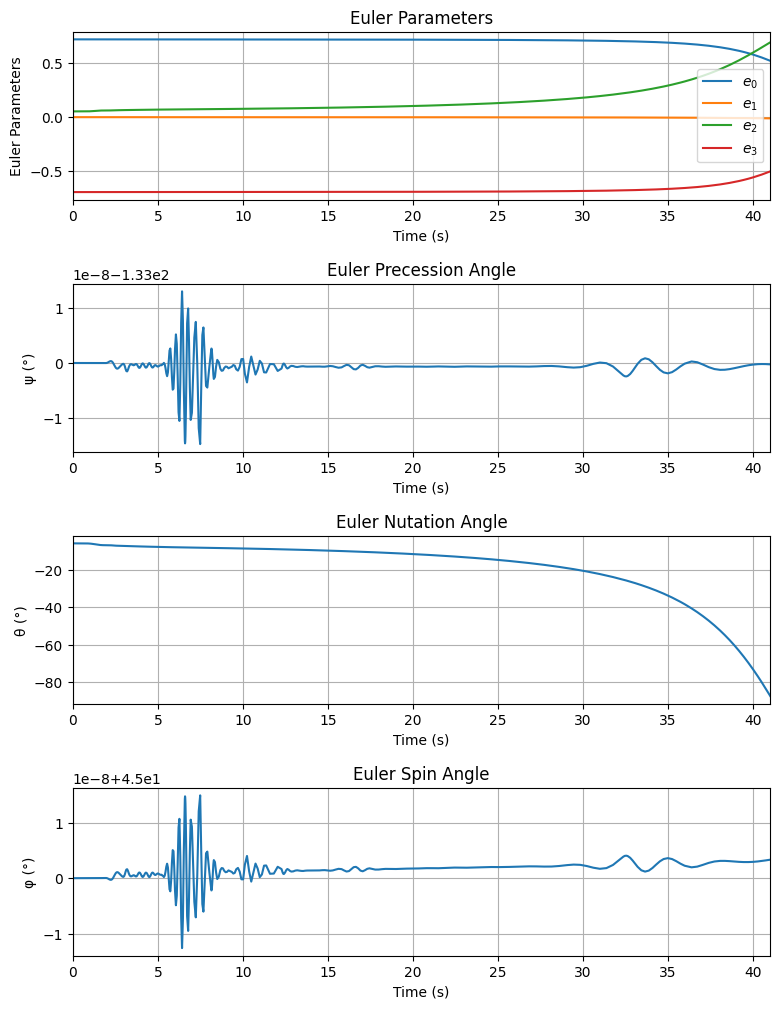



Trajectory Angular Velocity and Acceleration Plots



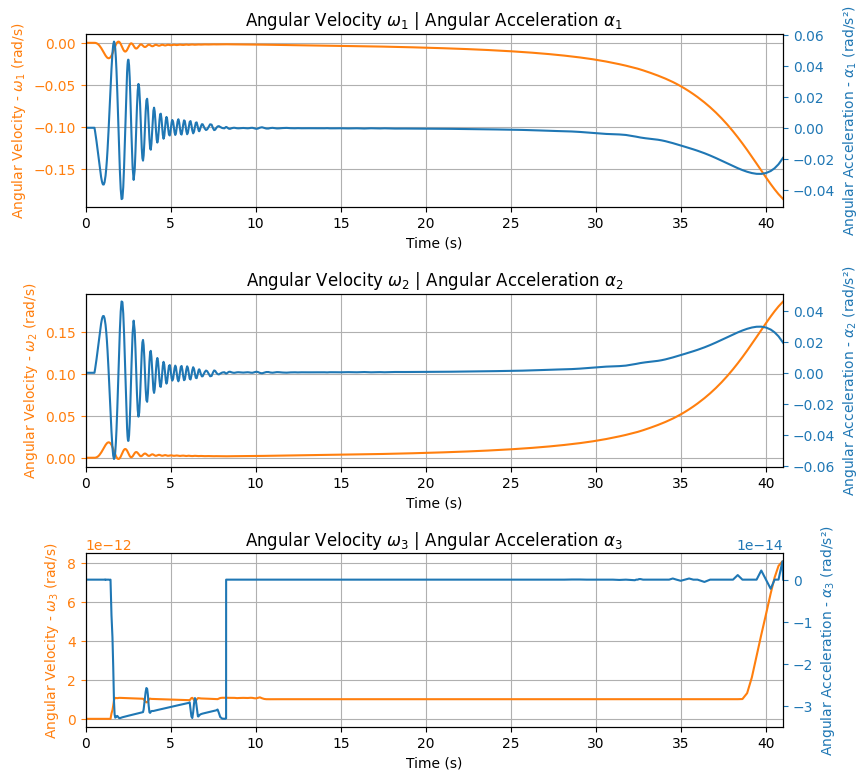



Aerodynamic Forces Plots



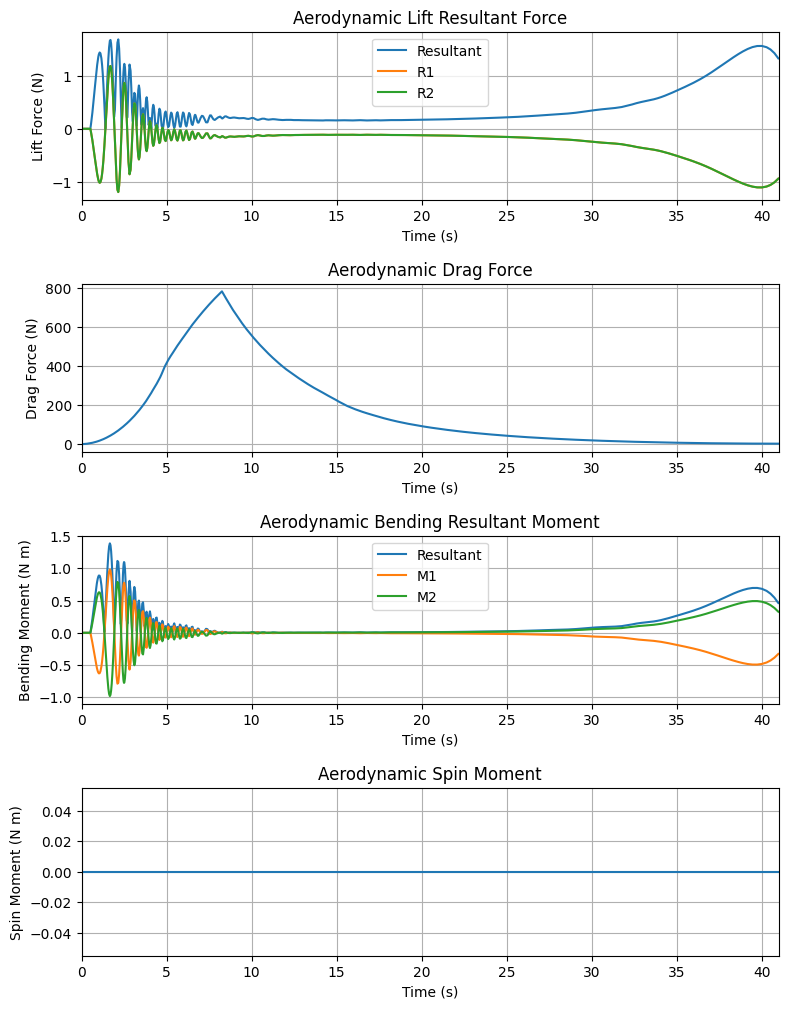



Rail Buttons Forces Plots



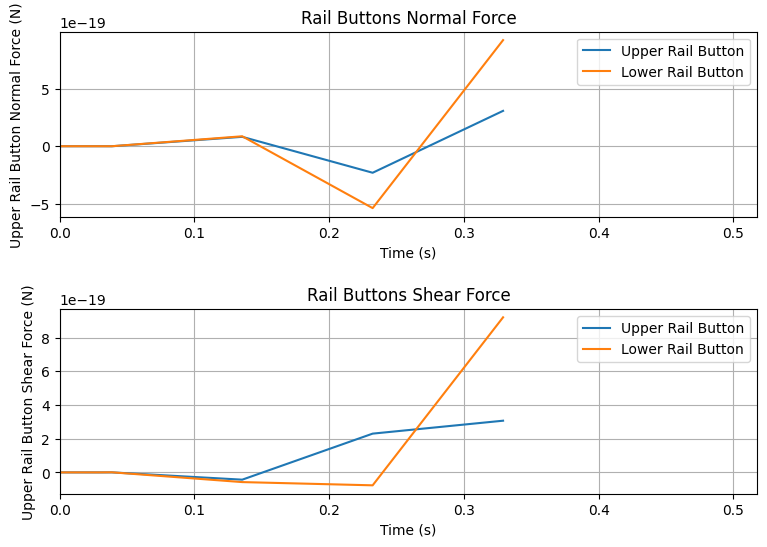



Trajectory Energy Plots



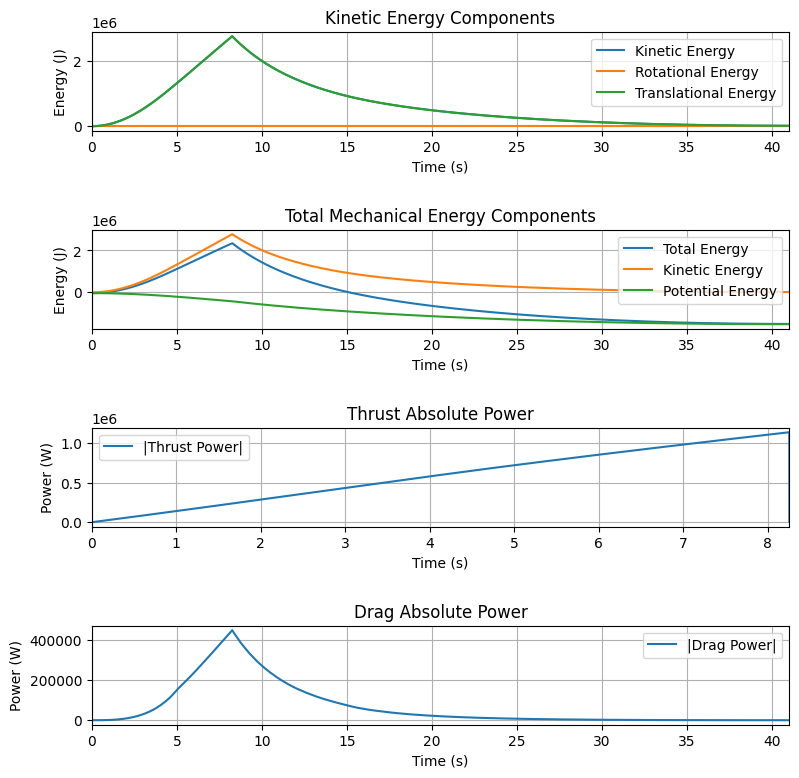



Trajectory Fluid Mechanics Plots



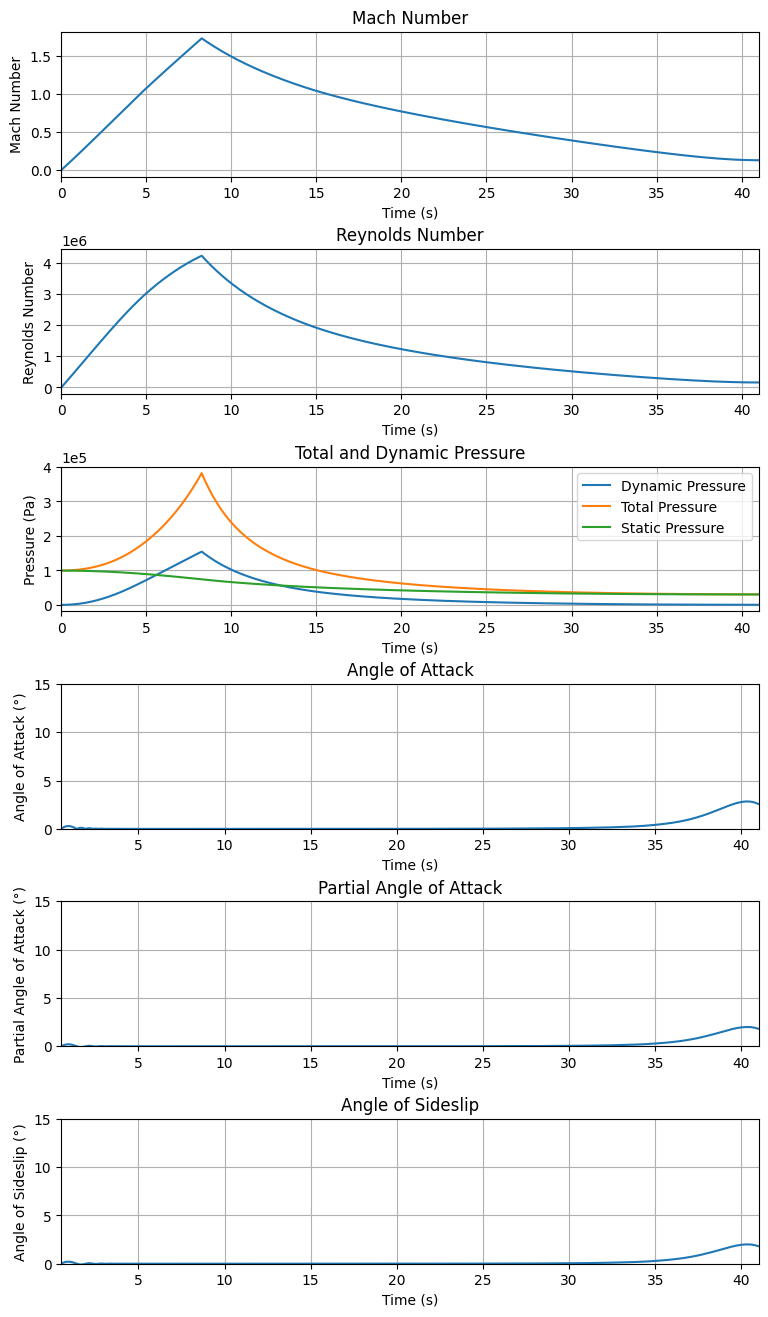



Trajectory Stability and Control Plots



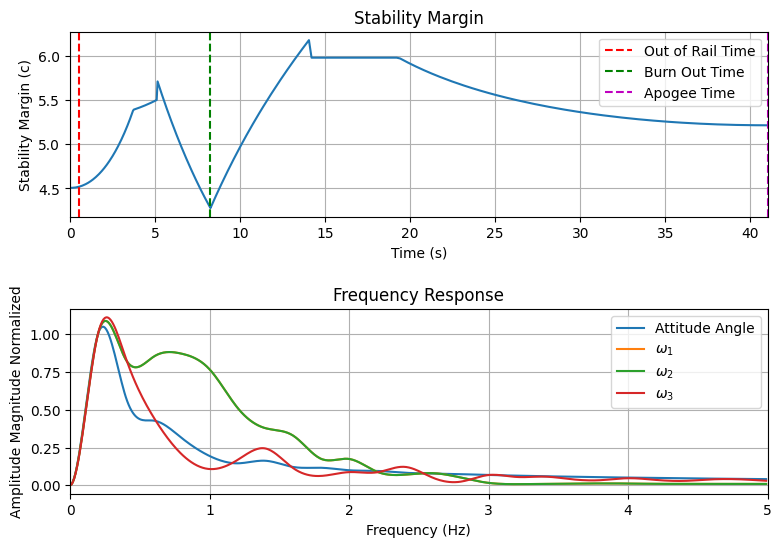



Rocket and Parachute Pressure Plots



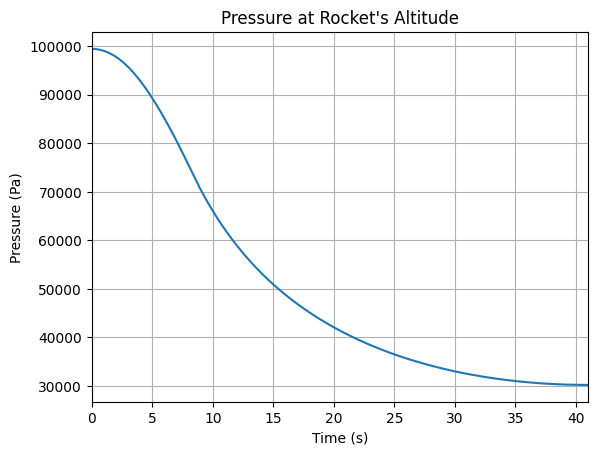


Rocket has no parachutes. No parachute plots available


In [13]:
flight_lists = []

for config in config_dict_list:
    flag_list = flag_lists[config_dict_list.index(config)]
    env_list = env_lists[config_dict_list.index(config)]
    propulsion_list = propulsion_lists[config_dict_list.index(config)]
    rocket_list = rocket_lists[config_dict_list.index(config)]

    rail_length = config_dict["Flight"]["flight"]["rail_length"]["Value"]
    inclination = config_dict["Flight"]["flight"]["inclination"]["Value"]
    heading = config_dict["Flight"]["flight"]["heading"]["Value"]
    
    # define Flight
    flight_normal = Flight(
        rocket = rocket_list["hedy"],
        environment = env_list["env_normal"],
        rail_length = rail_length,
        inclination = inclination,
        heading = heading,
        name = config,
        terminate_on_apogee = flag_list["terminate_on_apogee"]
    )
    flight_forecast = Flight(
        rocket = rocket_list["hedy"],
        environment = env_list["env_normal"],
        rail_length = rail_length,
        inclination = inclination,
        heading = heading,
        name = config,
        terminate_on_apogee = flag_list["terminate_on_apogee"]
    )

    flight_normal.all_info()

    flight_lists.append({
        "flight_normal": flight_normal, 
        "flight_forecast": flight_forecast
    })

    #flight.all_info()


## Comparison

Compare the different flights created with the individual config dictionaries

In [ ]:
comparison = CompareFlights(flight_list)
comparison.trajectories_3d(legend=True)
flight_list[0].all_info()
for flight in flight_list:
    print(f"Config: {flight.name} | Apogee: {flight.apogee.round()}")
    flight.stability_margin()

#fin_set.draw()

#hedy.draw()

#propulsion_system.all_info()